In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df=pd.read_csv('/content/drive/MyDrive/911.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [8]:
df.head(5)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


What is the top 5 zip code?

In [9]:
df['zip'].value_counts().head(5)

,count
zip,
19401.0,6979
19464.0,6643
19403.0,4854
19446.0,4748
19406.0,3174


What is the top 5 township?

In [10]:
df['twp'].value_counts().head(5)

,count
twp,
LOWER MERION,8443
ABINGTON,5977
NORRISTOWN,5890
UPPER MERION,5227
CHELTENHAM,4575


How many accident happened?

In [11]:
df['title'].nunique()

110

In [12]:
#Reason column : ems, fire,traffic
df['reason']=df['title'].apply(lambda title: title.split(':')[0])

In [13]:
df['reason'].value_counts()

,count
reason,
EMS,48877
Traffic,35695
Fire,14920


/tmp/ipykernel_5323/939641119.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reason',data=df,palette='viridis')


<Axes: xlabel='reason', ylabel='count'>

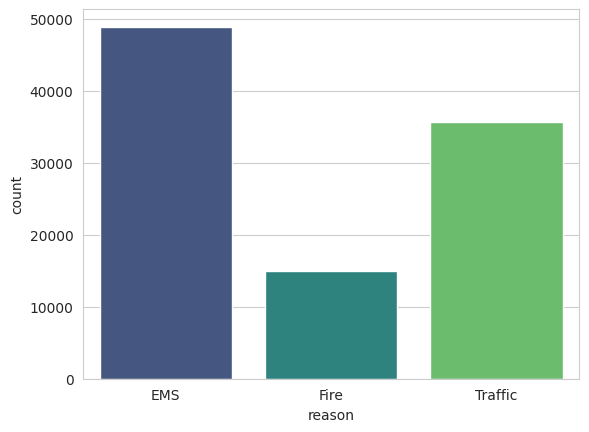

In [14]:
sns.countplot(x='reason',data=df,palette='viridis')

In [15]:
type(df['timeStamp'].iloc[0])

str

In [16]:
df['timeStamp'].iloc[0]

'2015-12-10 17:40:00'

In [17]:
df['timestamp']=pd.to_datetime(df['timeStamp'])

In [18]:
time=df['timestamp'].iloc[0]
time.hour

17

In [19]:
df['hour']=df['timestamp'].apply(lambda time: time.hour)
df['month']=df['timestamp'].apply(lambda time: time.month)
df['day of week']=df['timestamp'].apply(lambda time: time.dayofweek)


In [20]:
df['day of week']

,day of week
0,3
1,3
2,3
3,3
4,3
...,...
99487,2
99488,2
99489,2
99490,2


In [21]:
dmap={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'sun'}

In [22]:
dmap

{0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'sun'}

In [23]:
df['day of week']=df['day of week'].map(dmap)
df['day of week']

,day of week
0,Thu
1,Thu
2,Thu
3,Thu
4,Thu
...,...
99487,Wed
99488,Wed
99489,Wed
99490,Wed


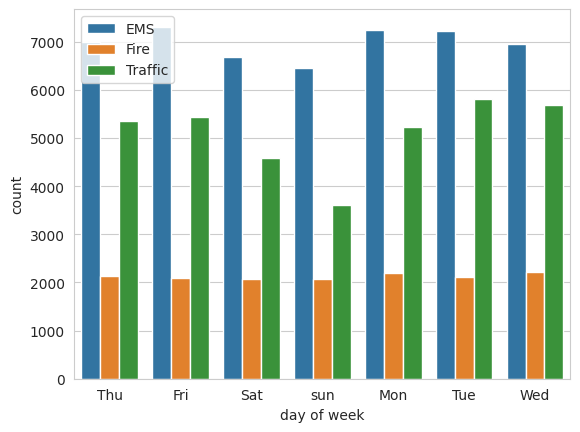

In [24]:
sns.countplot(x='day of week', hue='reason',data=df)
plt.legend(loc=2)

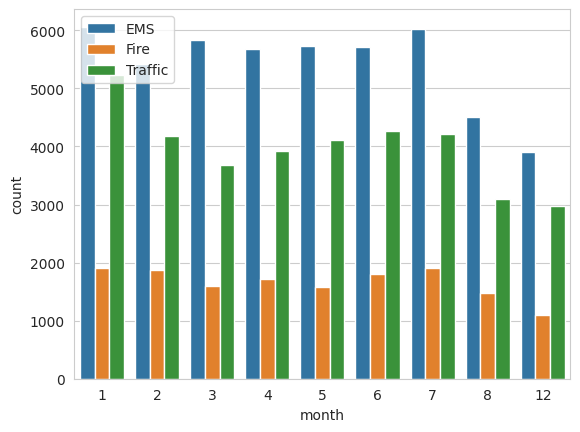

In [25]:
sns.countplot(x='month', hue='reason',data=df)
plt.legend(loc=2)

In [26]:
aylar_uzre=df.groupby('month').count()
aylar_uzre

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,reason,timestamp,hour,day of week
month,,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423,11423
6,11786,11786,11786,10212,11786,11786,11777,11732,11786,11786,11786,11786,11786
7,12137,12137,12137,10633,12137,12137,12133,12088,12137,12137,12137,12137,12137
8,9078,9078,9078,7832,9078,9078,9073,9025,9078,9078,9078,9078,9078
12,7969,7969,7969,6907,7969,7969,7963,7916,7969,7969,7969,7969,7969


<Axes: xlabel='month'>

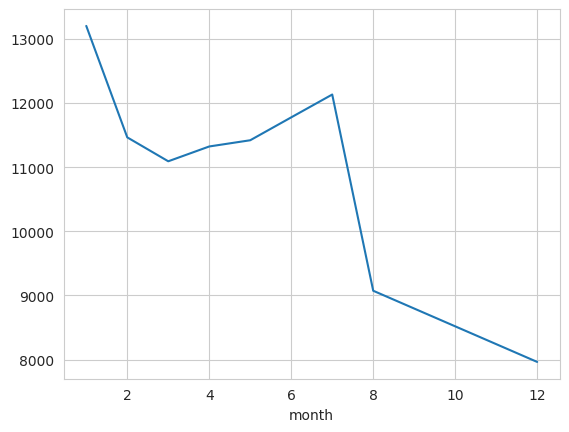

In [27]:
aylar_uzre['twp'].plot()

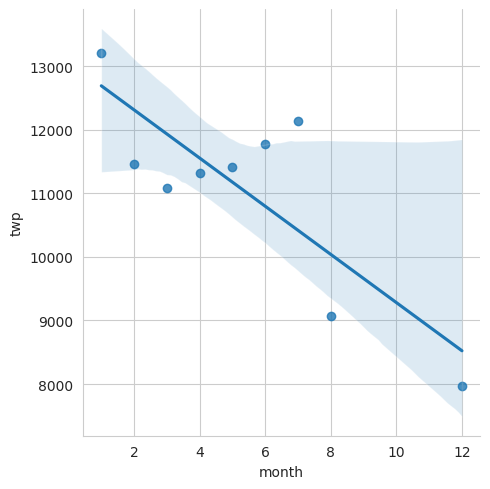

In [28]:
sns.lmplot(x='month',y='twp',data=aylar_uzre.reset_index())

In [29]:
df['date']=df['timestamp'].apply(lambda time: time.date())
df['date']

,date
0,2015-12-10
1,2015-12-10
2,2015-12-10
3,2015-12-10
4,2015-12-10
...,...
99487,2016-08-24
99488,2016-08-24
99489,2016-08-24
99490,2016-08-24


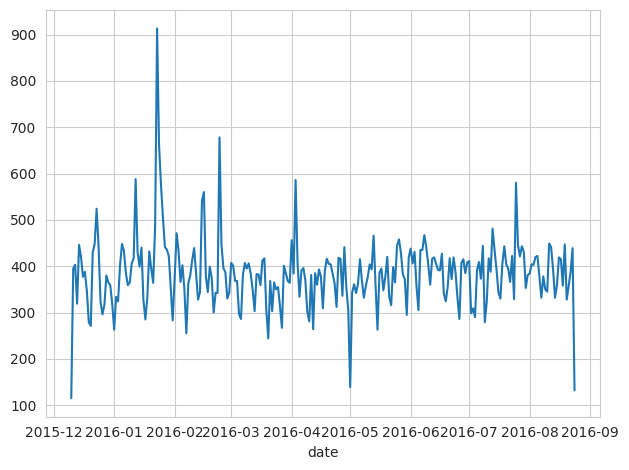

In [30]:

df.groupby('date').count()['twp'].plot()
plt.tight_layout()


Text(0.5, 1.0, 'traffic')

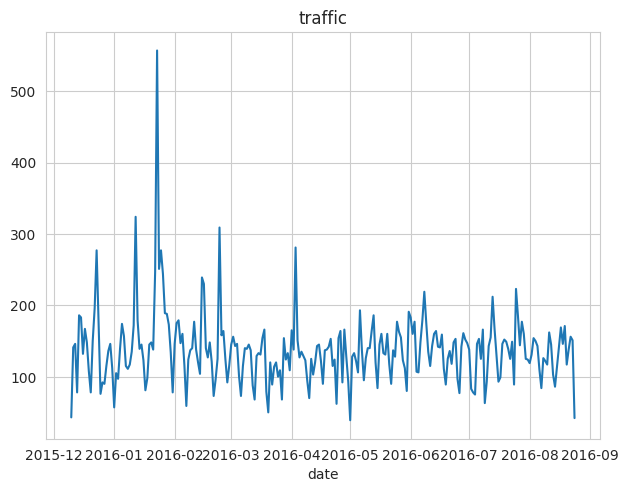

In [31]:
df[df['reason']=='Traffic'].groupby('date').count()['twp'].plot()
plt.tight_layout()
plt.title('traffic')

Text(0.5, 1.0, 'EMS')

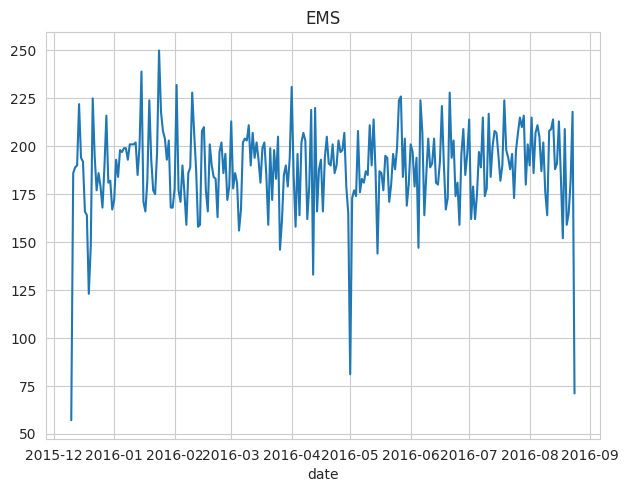

In [32]:
df[df['reason']=='EMS'].groupby('date').count()['twp'].plot()
plt.tight_layout()
plt.title('EMS')

Text(0.5, 1.0, 'Fire')

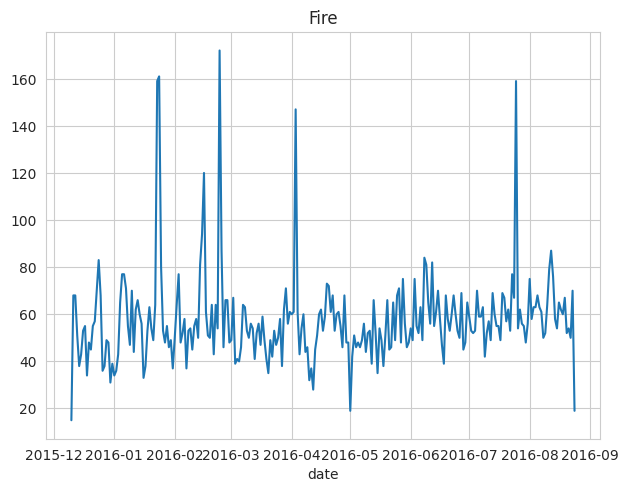

In [33]:
df[df['reason']=='Fire'].groupby('date').count()['twp'].plot()
plt.tight_layout()
plt.title('Fire')

In [34]:
gunsaat=df.groupby(by=['day of week','hour']).count()['reason'].unstack()
gunsaat

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day of week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354
Tue,269,240,186,170,209,239,415,655,889,880,...,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,...,904,867,990,1037,894,686,668,575,490,335
sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330


<Axes: xlabel='hour', ylabel='day of week'>

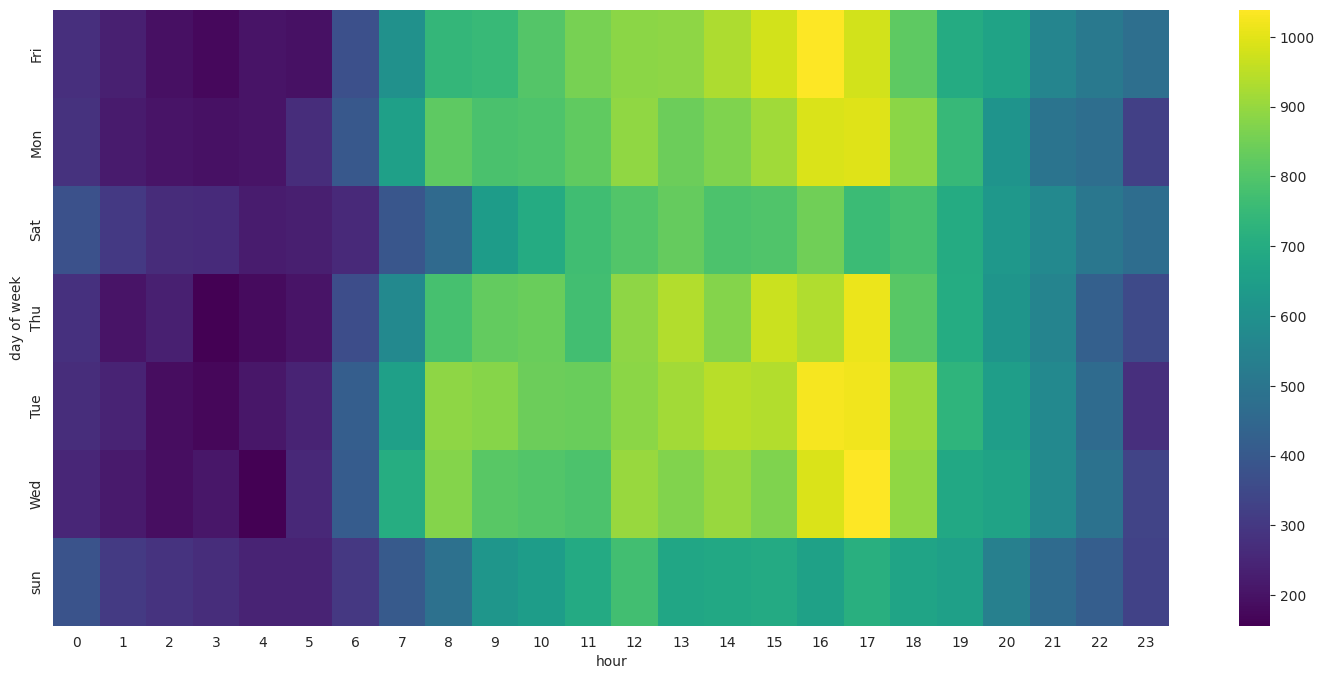

In [35]:
plt.figure(figsize=(18,8))
sns.heatmap(gunsaat,cmap='viridis')

In [36]:
gunay=df.groupby(by=['day of week','month']).count()['reason'].unstack()
gunay

month,1,2,3,4,5,6,7,8,12
day of week,,,,,,,,,
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266
Tue,1973,1753,1884,1430,1918,1676,1670,1612,1234
Wed,1700,1903,1889,1517,1538,2058,1717,1295,1262
sun,1960,1229,1102,1488,1424,1333,1672,1021,907


<Axes: xlabel='month', ylabel='day of week'>

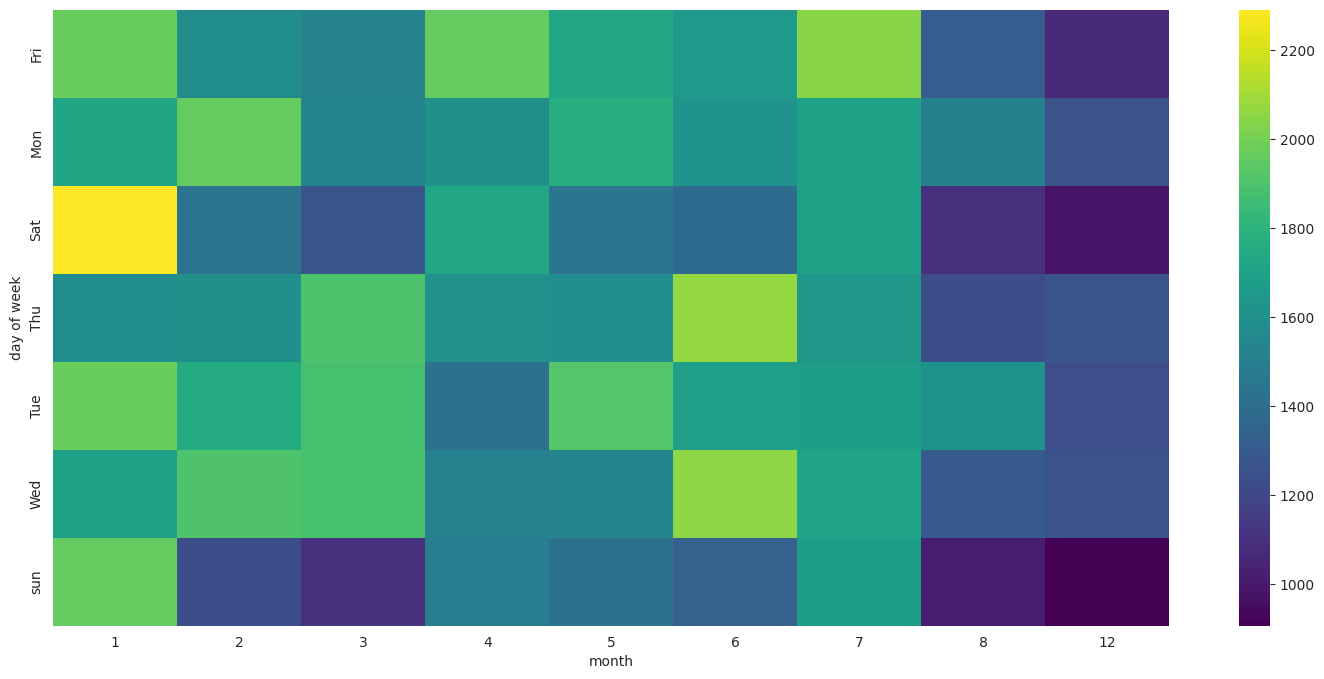

In [37]:
plt.figure(figsize=(18,8))
sns.heatmap(gunay,cmap='viridis')